# Stochastic calculus



In [1]:
from numpy.random import lognormal, uniform, normal
from numpy import exp, linspace ,log, max, mean ,  sqrt, arange
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sympy import symbols, expand, factor, diff, E, Function, maximum, Derivative, collect, simplify


## Ito Processes and Lemma



1. <font color='blue'>**Ito process:** </font> a stochastic process of the form :<br><br>
$\boxed{dX_t = \Theta(t,X_t)dt + \Psi(t, X_t)dW_t}$ <br><br>

1.  <font color='blue'>**Ito Lemma (1D):**</font> let $G(t,X_t)$ be a function of time and the ito process $X(t)$. Then we have <br><br>
    $\boxed{dG = \left(G_t + \Theta(t,X_t)G_x + \dfrac{1}{2}\Psi^2(t, X_t)G_{xx}\right) dt  + \Psi(t, X_t)G_xdW_t }$<br><br>
    
1. <font color='blue'>**Ito Lemma (2D):**</font>  let $G(t,X_t, Y_t)$ be a function of time $t$, the ito process $X(t)$ and $Y(t)$. Then we have <br><br>
$\boxed{dG = G_t dt + (G_x dX_t +  \dfrac{1}{2}G_{xx} dX_t dX_t) + (G_y dY_t +  \dfrac{1}{2}G_{yy} dY_t dY_t) + G_{xy}dX_t dY_t}$<br><br>

1. <font color='blue'>**Ito process with jump:**</font> An ito process with jump is of the form <br><br>
$\boxed{dX_t = \Theta(t,X_t)dt + \Psi(t, X_t)dW_t  + J(t, X_t) d{X_\mathcal{P}}_t} $  <br><br>

1. <font color='blue'>**Ito Lemma with jump:**</font> let $G(t,X_t)$ be a function of time and the process $X(t)$. Then we have  <br><br>
$\boxed{dG = \left(G_t + \Theta(t,X_t)G_x + \dfrac{1}{2}\Psi^2(t, X_t)G_{xx}\right) dt  + \Psi(t, X_t)G_xdW_t + \left[  G\left(t, X_t + J(t, X_t)\right) - G(t, X_t)    \right] d{X_\mathcal{P}}_t}$<br><br>

1. <font color='blue'>**Ito table:**</font> <br>
<kbd> 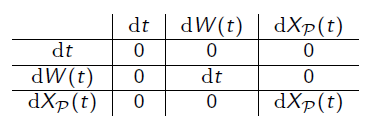
 
1. <font color='blue'>**Ito Lemma code:**</font> Below is a code that compute ito lemmas for us

In [2]:


t , X_t, Y_t, dt, dW_t, dXp_t, J= symbols('t X_t Y_t dt dW_t d{X_\mathcal{P}}_t J ')
X = symbols('X')
def my_simplify(expr):
    return collect( expand(expr)
                   .subs(dW_t**2, dt)
                   .subs(dW_t*dt, 0)
                   .subs(dt**2, 0)
                   .subs(dXp_t**2,dXp_t)
                   .subs(dXp_t*dt,0)
                   .subs(dXp_t*dW_t,0) ,
                   
                   (dt,dW_t, dXp_t) )

def ito_lemma(G = Function('G')(t,X_t), Θ = Function('Θ')(t,X_t), Ψ = Function('Ψ')(t, X_t)):
    G_t = diff(G, t)
    G_x = diff(G, X_t)
    G_xx = diff(G_x, X_t)
    
    dG = (G_t + Θ * G_x + 0.5 * pow(Ψ,2) * G_xx )*dt + Ψ * G_x * dW_t
    return my_simplify(dG)

def ito_lemma_2D(G = Function('G')(t,X_t, Y_t), 
                 dX_t = Function('Θ_1')(t,X_t,Y_t)*dt +  Function('Ψ_1')(t,X_t,Y_t)*dW_t, 
                 dY_t = Function('Θ_2')(t,X_t,Y_t)*dt +  Function('Ψ_2')(t,X_t,Y_t)*dW_t ):
    G_t = diff(G, t)
    G_x = diff(G, X_t)
    G_xx = diff(G_x, X_t)
    G_y = diff(G, Y_t)
    G_yy = diff(G_y, Y_t)
    G_xy = diff(G_x, Y_t)
    
    dG = G_t*dt + ( G_x * dX_t + 1/2 * G_xx*dX_t*dX_t)  + ( G_y * dY_t + 1/2 * G_yy*dY_t*dY_t) + G_xy * dX_t*dY_t 
    
    return dG

def ito_lemma_jump(G = Function('G')(t,X_t), Θ = Function('Θ')(t,X_t), Ψ = Function('Ψ')(t, X_t), J = Function('J')(t, X_t)  ):
    G_t = diff(G, t)
    G_x = diff(G, X_t)
    G_xx = diff(G_x, X_t)
    G_j = G.subs(X_t, X_t +J ) - G  

    dG = (G_t + Θ * G_x + 0.5 * pow(Ψ,2) * G_xx )*dt + Ψ * G_x * dW_t + G_j*dXp_t
    return my_simplify(dG)




## Martingales


### Definition of martingale

A stochastic process $X(t)$ is said to be a martingale if :
1. $X$ is adapted to filtration $\mathcal{F_{t>0}}$
2. $\forall t, \mathbb{E}[|X(t)| ] < \infty $
3. $\mathbb{E}\left[X(t)| \mathcal{F_s} \right] = X(s)$

### Stochastic integral Theorem

Let $X(t)$ be stochastic process that can be represented as either  
* $X(t) = \int_{0}^{t}g(s) \,dW(s)$  or 
* $dX(t) = g(t)dW(t)$

then the process $X(t)$ is a martingale. That is a process of that form with no drift is martingale



## Numeraire

1. In financial mathematics a numeraire is a tradable asset in terms of which the price of all other tradeble assets are expressed

1. When working with involved systems of Stochastic Differenial Equation (SDEs) it is sometimes possible to reduce the complexity of the math by an appropriate measure transformation 

1. Under the correct numaire change, processes may become martingale. Working with martigale is typically easier because the drift term is zero. <br>
For example consider:  $dSt = r(t) S(t) dt + \sigma S(t) dW_t $
    * If $r(t)$ is constant then we can simply use black-scholes formula to price put and call options <br>
    * If $r(t)$ is stochastic this become quite hard.
        * However if we find a numeraire change such that the drift term is 0 then we have
        *  $dSt =  0+ \sigma S(t)dW_t $ which is much simpler and again we can use black scholes
<br>
<br>
1. It can be shown that if we pick a tradable asset $\mathcal{N}$ as numeraire then under the generated measure $\mathbb{Q}^\mathcal{N}$ any asset divided my the numeraire will be a martingale

1. Consider $X(t)$ to be a tradedable asset. Three measure and the corresponding martigale property are as follow
    1. <font color='blue'>Risk Neutral measure $\mathbb{Q}$</font>
    This is a measure where the money saving account $M(t)$ is the numeraire <br><br>
    $\boxed{dX(t) = \mu^{\mathbb{Q}}(t)dt + \sigma(t)dW^{\mathbb{Q}}_t \implies \mathbb{E^Q} \left[ \dfrac{X(t)}{M(t)}|\mathscr{F}(t_0) \right]  = \dfrac{X(t_0)}{M(t_0)}} $ <br><br>
    
    1.  <font color='blue'>Forward  measure  $\mathbb{T}$</font>
    This is a measure where the zero coupon bond $P(t,T)$ is the numeraire  <br><br>
    $\boxed{dX(t) = \mu^{\mathbb{T}}(t)dt + \sigma(t)dW^{\mathbb{T}}_t \implies \mathbb{E^T} \left[ \dfrac{X(t)}{P(t,T)}|\mathscr{F}(t_0)   \right] = \dfrac{X(t_0)}{P(t_0,T)}}$ <br><br>
    
    1.  <font color='blue'>Stock  measure $\mathbb{S}$</font>
    This is a measure where the Stock $S(t_0)$ is the numeraire  <br><br> 
    $\boxed{dX(t) = \mu^{\mathbb{S}}(t)dt + \sigma(t)dW^{\mathbb{S}}_t \implies \mathbb{E^S} \left[ \dfrac{X(t)}{S(t)}|\mathscr{F}(t_0)   \right] = \dfrac{X(t_0)}{S(t_0)}}$<br><br>
    
    1.  <font color='blue'>Annuity  measure  $\mathbb{A}_{i,m}$</font>
    This is a measure where the Annuity $A_{i,m}$ is the numeraire  <br><br>
    


## The Girsanov Theorem


1. Consider the following stochastic process for $X(t)$ :   $$dX_t = \mu^A\left(X_t\right)dt +\sigma\left(X_t\right)dW^A_t$$<br>
Where the brownian motion $dW^A_t$ is defined under the measure $\mathbb{Q}^A$<br>

1. For some drift $ \mu^B\left(X_t\right)$ define the ration: $$Y(t) = \dfrac{\mu^B\left(X_t\right) - \mu^A\left(X_t\right)}{\sigma\left(X_t\right)}$$ <br><br>

1. Define the measure $\mathbb{Q}^B$ by : $$\dfrac{\text{d}\mathbb{Q}^B}{\text{d}\mathbb{Q}^A} = \text{exp}\left( \int^t_0 Y(s)dW^A_s -\dfrac{1}{2}\int^t_0 Y^2(s)ds\right) $$<br>

1. The measure $\mathbb{Q}^B$ is equivalent to the measure $\mathbb{Q}^A$ 

1. $dW^B_t$ is a brownian motion under $\mathbb{Q}^B$ with : $$dW^B_t = dW^A_t - Y(t)dt $$

1. the process of $X(t)$ under $\mathbb{Q}^B$ is :  $$dX_t = \mu^B\left(X_t\right)dt + \sigma\left(X_t\right)dW^B_t$$

1. we can also have the relation : $$dX_t = \left( \mu^A\left(X_t\right)  + Y(t)\sigma\left(X_t\right)\right)dt + \sigma\left(X_t\right)dW^B_t$$

## The Feynman-Kac Theorem

1. This theorem connects the solution of a specific class of partial differentials equations to an expectation.

1. Consider the Ito process  $$dX_t = \Theta(t,X_t)dt + \Psi(t, X_t)dW_t$$

1. Assume that $V(t,X)$ is the solution to the stochastic process <br>  
$$ V_t +\Theta(t,X_t) V_x +\frac{1}{2} \Psi^2(t,X_t) V_{xx} - rV  = 0$$

1. With the boundary condition (pay-off function) $$V(T, X) = H(X)$$

1. The solution of the PDE is $$V(t,X) = \mathbb{E} \left[ H(X_T)e^{-\int_t^Trdu} \right]$$


## Fundamental theorem of Asset pricing

1. Let $V(T, S_T)$ be and $\mathscr{F}(T)$-measurable random variable. 

1. This represents the payoff at time $T$ of a derivative security
1. Remember $\mathscr{F}(T)$-measurability means depends on anything that happens between time $0$ and time $T$
1. That is we allow the payoff to be path dependent
1. We may write $$\boxed{V(t, S_t) = \mathbb{E^Q} \left[ V(T)\times D(t,T)|\mathscr{F}(t) \right] }$$

## Change of measure examples

### Black-Scholes Model (1973)


1. We start by assuming that :
 $$d S(t) = \mu S(t) dt + \sigma  S(t) dW^{\mathbb{P}}(t)$$
 $$dM(t) = rM(t)dt$$
 
2. We define $V(t,S(t))$ as the value of a derivative at time $t$



In [3]:
from sympy import symbols, expand, factor, diff, E, Function, maximum, Derivative, collect, simplify

# in the case of the stock price
X_t = S_t = symbols('S_t')
μ, σ, Δ_t, r, M_t = symbols('μ σ Δ_t r M_t')

# The stock is an Ito process with the drift and diffusion term defined as bellow under the real measure P
θ = μ*S_t
Ψ = σ*S_t

# The stock is defined as 
dS_t = θ*dt + Ψ*dW_t

# the money market account is defined as 
dM_t = r*M_t*dt

# the derivative is defined as function of the stock 
V = Function('V')(t,S_t)



#### Derivation by riskless portfolio construction

1. Let $\Pi$ be the value of a portfolio made of 1 derivative and short $\Delta(t)$ shares of the stock.  $$\Pi(t) = V(t) - \Delta(t)S(t)$$
1. The change in the value of the protfolio is given by $$d\Pi(t) = dV(t) - \Delta(t)dS(t)$$
1. In this approach the goal is to set up the portfolio such that it is riskless
1. Naturally if the portfolio is riskless then it should earn the risk free rate $r$
1. The dynamic of the portfolio $\Pi$ is given by Ito lemmas as below

In [4]:
# the portfolio definition
Π = V - Δ_t * S_t

# The dinamics of the portfolio and derivative are given by Ito's lemma
dV = ito_lemma(G = V,  Θ = θ, Ψ = Ψ)
dΠ = ito_lemma(G = Π,  Θ = θ, Ψ = Ψ )

print('dΠ follows the process  :')
display(dΠ)

dΠ follows the process  :


dW_t*(-S_t*Δ_t*σ + S_t*σ*Derivative(V(t, S_t), S_t)) + dt*(0.5*S_t**2*σ**2*Derivative(V(t, S_t), (S_t, 2)) - S_t*Δ_t*μ + S_t*μ*Derivative(V(t, S_t), S_t) + Derivative(V(t, S_t), t))

6. from the results in the previous Cell we have $$d\Pi =  dW_{t} \left(- S_{t} Δ_{t} σ + S_{t} σ \frac{\partial}{\partial S_{t}} V{\left(t,S_{t} \right)}\right) + dt \left(0.5 S_{t}^{2} σ^{2} \frac{\partial^{2}}{\partial S_{t}^{2}} V{\left(t,S_{t} \right)} - S_{t} Δ_{t} μ + S_{t} μ \frac{\partial}{\partial S_{t}} V{\left(t,S_{t} \right)} + \frac{\partial}{\partial t} V{\left(t,S_{t} \right)}\right)$$

1. if we want this portfolio to be riskless we must have the term multiplying $dW_t$ is zero that is: $$ \Delta(t) = \frac{ \partial V(t, S_t)}{ \partial S_t}$$

1. If the portfolio is riskless hence, we must also have $$d\Pi = r \Pi dt$$

1. In the code below we 
    *  do the substitution $\Delta(t) = \frac{ \partial V(t, S_t)}{ \partial S_t}$ in $d\Pi$
    *  then do the algebra $ d\Pi - r \Pi dt = 0 $ 

In [5]:
# Do the algebra in points 7
my_simplify((dΠ  - r*Π*dt).subs(Δ_t,Derivative(V, S_t) ))


dt*(0.5*S_t**2*σ**2*Derivative(V(t, S_t), (S_t, 2)) + S_t*r*Derivative(V(t, S_t), S_t) - r*V(t, S_t) + Derivative(V(t, S_t), t))

10. The Famous Blacks scholes equation is given by the results above $$  \frac{\partial}{\partial t} V{\left(t,S_{t} \right) +\frac{1}{2} S_{t}^{2} σ^{2} \frac{\partial^{2}}{\partial S_{t}^{2}} V{\left(t,S_{t} \right)} + S_{t} r \frac{\partial}{\partial S_{t}} V{\left(t,S_{t} \right)} - r V{\left(t,S_{t} \right)} =0}$$

1. Note that on this expression $\mu$ appears no where !

#### Risk neutral measure approach




##### From $\mathbb{P} \text{ to } \mathbb{Q}$

* Under the $\mathbb{P}$ the stock follows the process $dS_t = \mu S_t dt +\sigma S_t dW^{\mathbb{P}}_t$

* We define the discounted stock process as $F(t, S_t, M_t) = \dfrac{S_t}{M_t}$

* Under  $\mathbb{Q}$ we must have $F(t, S_t, M_t)$  is martigale as $M_t$ is the numaire

* We can find the dynamics of $F(t, S_t, M_t)$ under $\mathbb{P}$ using ito lemma see code below<br>

In [6]:
# set up to use 2 factor ito lemma
X_t = S_t
Y_t = M_t
F = S_t / M_t
print(" the dynamics of F, the discounted stock process is given by : ")
my_simplify(ito_lemma_2D(G = F, dX_t = dS_t,   dY_t = dM_t ))

 the dynamics of F, the discounted stock process is given by : 


dt*(-S_t*r/M_t + S_t*μ/M_t) + S_t*dW_t*σ/M_t

* Applying the ito lemma rule we have: <br><br> $dF = (\mu - r)\dfrac{S_t}{M_t}dt+ \dfrac{S_t}{M_t}\sigma dW^{\mathbb{P}}_t$

* Under  $\mathbb{Q}$ we must have $F$ is martigale, and we know the diffusion term does not change from one measure to the next hence : <br><br>
$dF =\dfrac{S_t}{M_t}\sigma dW^{\mathbb{Q}}_t$

* Hence have : <br><br> $dF =\dfrac{S_t}{M_t}\sigma dW^{\mathbb{Q}}_t = (\mu - r)\dfrac{S_t}{M_t}dt+ \dfrac{S_t}{M_t}\sigma dW^{\mathbb{P}}_t$

* After simplication we have the relation that determine the measure transformation from  $\mathbb{P}$  to  $\mathbb{Q}$ <br><br>
$\boxed{dW^{\mathbb{P}}_t = dW^{\mathbb{Q}}_t - \left(\dfrac{\mu-r}{\sigma}\right)dt} $ <br><br>

* for example the stock process transformation can be done following: <br><br>
$
\begin{align}
dS_t &= \mu S_t dt +\sigma S_t dW^{\mathbb{P}}_t \\
&=\mu S_t dt +\sigma S_t \left( dW^{\mathbb{Q}}_t - \left(\dfrac{\mu-r}{\sigma}\right)dt\right)\\
 &= r S_t dt +\sigma S_t dW^{\mathbb{Q}}_t 
\end{align}
$


##### Martingale approach to black scholes option pricing

* Under the risk neutral measure the process for the stock is given by: <br>$ dS_t = r S_t dt +\sigma S_t dW^{\mathbb{Q}}_t $

* The discounted option value $F(t, S_t, M_t)  =V(S_t, t) / M(t)$ should be a martingale 

* Using ito lemma we can find the process of the discounted stock under $\mathbb{Q}$

In [7]:
# under the risk neutral world the drift change
θ = r*S_t
Ψ = σ*S_t

# the dinamics of the stock, money market, and derivative V are
dS_t = θ*dt + Ψ*dW_t
dM_t = r*M_t*dt
V = Function('V')(t,S_t)
dV = ito_lemma(G=V , Θ=θ , Ψ=Ψ)

# using ito lemma to get the dynamic of F the discounted derivative price is
X_t = S_t
Y_t = M_t
F = V /M_t
dF = ito_lemma_2D(G = F,  dX_t = dS_t, dY_t = dM_t)
my_simplify(  dF )

dt*(0.5*S_t**2*σ**2*Derivative(V(t, S_t), (S_t, 2))/M_t + S_t*r*Derivative(V(t, S_t), S_t)/M_t - r*V(t, S_t)/M_t + Derivative(V(t, S_t), t)/M_t) + S_t*dW_t*σ*Derivative(V(t, S_t), S_t)/M_t

* because we are in the risk neutral world, $F(t, S_t, M_t)  =V(S_t, t) / M(t)$ should be a martingale that is the drift should be zero

* hence we  have the black-scholes equation again:
 $$  \frac{\partial}{\partial t} V{\left(t,S_{t} \right) +\frac{1}{2} S_{t}^{2} σ^{2} \frac{\partial^{2}}{\partial S_{t}^{2}} V{\left(t,S_{t} \right)} + S_{t} r \frac{\partial}{\partial S_{t}} V{\left(t,S_{t} \right)} - r V{\left(t,S_{t} \right)} =0}$$


### The stock as numeraire $\mathbb{S}$

#### Changing the numeraire to $S_t$ to simplifies the pricing 

1. Assume Black-Scholes martket, with the money saving account $M(t)$ and l standard log normal model for $S(t)$
     
    $\begin{cases}
    dS_t = r S_t dt +\sigma S_t dW^{\mathbb{Q}}_t\\ \\
   dM_t = r M_t dt
\end{cases}$
    <br><br>
2. We want to determine the price of the following derivative: <br>
$ V(t_0) = \mathbb{E^Q}\left[  \dfrac{1}{M(T)}  \text{max}\left(S^2(T) - S(T) K, 0 \right) | \mathscr{F}(t_0) \right]$

3. to do this we will change the numeraire from the money saving account to the stock. We define the following Radon-Nikodym derivative <br><br>
$\dfrac{d\mathbb{S}}{d\mathbb{Q}} = \dfrac{S(T)}{S(t_0)} \dfrac{M(t_0)}{M(T)} \implies d\mathbb{Q} =  \color{purple}{\dfrac{S(t_0)}{S(T)} \dfrac{M(T)}{M(t_0)}d\mathbb{S}}$

4. the expectation becomes <br><br>
$
\begin{align}
V(t_0) &= \mathbb{E^Q}\left[  \frac{1}{M(T)}  \text{max}\left(S^2(T) - S(T) K, 0 \right) | \mathscr{F}(t_0) \right] \\
       & = \int_{\Omega}\frac{1}{M(T)}\text{max}\left(S^2(T) - S(T) K, 0 \right) d\mathbb{Q} \\
       & = \int_{\Omega}\frac{1}{M(T)}\text{max}\left(S^2(T) - S(T) K, 0 \right) \color{purple} {\frac{S(t_0)}{S(T)} \frac{M(T)}{M(t_0)}d\mathbb{S}} \\
       & = \dfrac{S(t_0)}{M(t_0)}\int_{\Omega}\text{max}\left(S(T) -  K, 0 \right)  d\mathbb{S} \\
       &= \dfrac{S(t_0)}{M(t_0)} \mathbb{E^S}\left[  \text{max}\left(S(T) -  K, 0 \right) | \mathscr{F}(t_0) \right] \\
\end{align}
$




#### Finding the dinamic of $S_t$ under the measure $\mathbb{S}$ 

* Using ito lemma (code below) we can find  the dynamics of $F(t, M_t, S_t) = \dfrac{M_t}{S_t}$ under $\mathbb{Q}$ <br><br>


In [8]:
M_t, S_t,r,   σ, μ,dW_P_t  = symbols('M_t S_t r σ μ dW^{\mathbb{P}}_t')
Θ = r*S_t
Ψ = σ*S_t
# Define the process for the stock and money market under Q
dS_t = Θ*dt + Ψ*dW_t
dM_t = r*M_t*dt

# set up to use 2 factor ito lemma
Y_t = M_t
X_t = S_t
F = M_t / S_t
my_simplify(ito_lemma_2D(G = F, dX_t = dS_t,   dY_t = dM_t ))

-M_t*dW_t*σ/S_t + 1.0*M_t*dt*σ**2/S_t

* we have the dynamic is given by <br><br> $dF = \sigma^2\dfrac{M_t}{S_t}dt - \sigma\dfrac{M_t}{S_t}dW^{\mathbb{Q}}_t$

* We know that under $\mathbb{S}$,   $F$ is a martingale and we know the diffusion term does not change from one measure to another hence <br><br>
$dF = - \sigma\dfrac{M_t}{S_t}dW^{\mathbb{S}}_t$

* That is we have <br><br> $dF = \sigma^2\dfrac{M_t}{S_t}dt - \sigma\dfrac{M_t}{S_t}dW^{\mathbb{Q}}_t = - \sigma\dfrac{M_t}{S_t}dW^{\mathbb{S}}_t$

* By simplifying we get the relation that determine the measure transformation from  $\mathbb{Q}$  to  $\mathbb{S}$   <br><br>
$\boxed{dW^{\mathbb{Q}}_t = dW^{\mathbb{S}}_t + \sigma dt} $ <br><br>

* for example the stock process transformation can be done following: <br><br>
$
\begin{align}
dS_t &= r S_t dt +\sigma S_t dW^{\mathbb{Q}}_t \\
     &= r S_t dt +\sigma S_t \left( dW^{\mathbb{S}}_t + \sigma dt\right)\\
     &= ( r + \sigma^2) S_t dt +\sigma S_t dW^{\mathbb{S}}_t 
\end{align}
$

* Finally with 
    * $V(t_0) = S_0 \mathbb{E^S}\left[  \text{max}\left(S(T) -  K, 0 \right) \right]$
    * $dS_t= ( r + \sigma^2) S_t dt +\sigma S_t dW^{\mathbb{S}}_t $ 
    
    we can price the option using black scholes model

### The T-forward measure

1. A ZCB is a contract with price $P(t,T)$ to deliver at time T, $P(T,T) = 1$

1. Whenever we have stochastic interest rates involved we may benefit from switching to the T-Forward measure associated with  $P(t,T)$

1. The fundamental theorem of asset pricing states that the price at time $t$ of any contingent claims with payoff $H(T)$ is given by <br><br>
$$\boxed{V(t) = \mathbb{E^{Q}} \left[  e^{-\int_t^T r(z)dz}H(T) | \mathscr{F}(t) \right]  }  $$

1. since  $P(t,T)$ is a tradable asset it can be used as a numeraire using the random nykodyn derivative we have <br><br>
$\dfrac{d\mathbb{T}}{d\mathbb{Q}} = \dfrac{P(T,T)}{P(t_0,T)} \dfrac{M(t_0)}{M(T)} \implies d\mathbb{Q} =  \color{purple}{\dfrac{P(t_0,T)}{P(T,T)} \dfrac{M(T)}{M(t_0)}d\mathbb{T}}$

1. The payoff of the contengent claim with stochastic discounting is <br><br>
$
\begin{align}
V(t_0) &=  \mathbb{E^{Q}} \left[  e^{-\int_t^T r(z)dz}H(T) | \mathscr{F}(t) \right]\\
     &= \int_{\Omega}\frac{1}{M(T)}H(T) d\mathbb{Q} \\
       &= \int_{\Omega}\frac{1}{M(T)}H(T)  \color{purple}{\dfrac{P(t_0,T)}{P(T,T)} \dfrac{M(T)}{M(t_0)}d\mathbb{T}} \\
        &= \frac{P(t_0,T)}{M(t_0)}\int_{\Omega}H(T) d\mathbb{T} \\
       &=P(t_0,T) \mathbb{E^{T}} \left[H(T) \big|\mathscr{F}(t) \right]
\end{align}
$
<br>
Note the stochastic discounting is gone !